In [12]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [13]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_imgs(imgs, x_crop, y_crop)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, dict_set_val_sat, intensities_imgs, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if dict_set_val_sat[intensities_imgs[i]] >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

function mask_condensate(xc, yc, a, b, θ, x_crop, y_crop)
    mask = ones(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 0
            end
        end
    end
    return mask
end

mask_condensate (generic function with 1 method)

In [14]:
pathdir = "Y:/TwoDGas/2026/01/19/0046"
I_set_value = [0.1:0.1:1;]
sat_exp = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # Estimated saturation parameter
dict_set_val_sat = Dict(I_set_value[i] => sat_exp[i] for i in eachindex(I_set_value))

τ_exp = 5e-6 # In s
x_crop = [1100:1700;]
y_crop = [1750:2450;]
wrong_shots = []
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

xc, yc, a, b, θ = 310, 350, 110, 60, 1.1;

In [15]:
if !isdir("imgs_surrounding_droplets")
    mkdir("imgs_surrounding_droplets")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_"))
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_"))
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end])
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end])
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask")
end

if !isdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask")
    mkdir("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask")
end

"imgs_surrounding_droplets/2026_01_19/0046/neg_ODs_mask"

# Import and crop the images

In [16]:
mask = mask_condensate(xc, yc, a, b, θ, x_crop, y_crop)
files_path = readdir(pathdir)
imgs_atoms, imgs_bkg, imgs_dark, intensities_imgs = load_imgs(files_path, pathdir)
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = crop_imgs(imgs_atoms, x_crop, y_crop), crop_imgs(imgs_bkg, x_crop, y_crop), crop_imgs(imgs_dark, x_crop, y_crop)
imgs_atoms_crop_surroundings, imgs_bkg_crop_surroundings, imgs_dark_crop_surroundings = [imgs.*mask for imgs in imgs_atoms_crop], [imgs.*mask for imgs in imgs_bkg_crop], [imgs.*mask for imgs in imgs_dark_crop];

In [17]:
@save "Imgs_crop_surroundings_droplet_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_surroundings imgs_bkg_crop_surroundings imgs_dark_crop_surroundings intensities_imgs

In [18]:
@load "Imgs_crop_surroundings_droplet_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_surroundings imgs_bkg_crop_surroundings imgs_dark_crop_surroundings intensities_imgs;

# Compute the ODs

In [19]:
ODs_dataset = compute_OD_high_low_intensity(imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, dict_set_val_sat, intensities_imgs, τ_exp)
ODs_dataset_surroundings = [OD.*mask for OD in ODs_dataset];

In [20]:
@save "ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*"_surroundings_droplet.jld2" ODs_dataset ODs_dataset_surroundings

In [21]:
@load "ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*"_surroundings_droplet.jld2" ODs_dataset ODs_dataset_surroundings;

# Save the ODs images

### ODs

In [22]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:01<00:33, 1it/s]
6.0%┣██▉                                             ┫ 3/50 [00:01<00:21, 2it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:17, 3it/s]
10.0%┣████▊                                          ┫ 5/50 [00:01<00:14, 3it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:01<00:13, 3it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:02<00:12, 4it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:02<00:11, 4it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:02<00:11, 4it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:02<00:10, 4it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:03<00:11, 4it/s]
24.0%┣███████████           

### ODs mask

In [23]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset_surroundings))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:00<00:22, 2it/s]
6.0%┣██▉                                             ┫ 3/50 [00:01<00:16, 3it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:14, 3it/s]
10.0%┣████▊                                          ┫ 5/50 [00:01<00:12, 4it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:01<00:11, 4it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:01<00:11, 4it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:02<00:10, 4it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:02<00:10, 4it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:02<00:09, 4it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:02<00:09, 4it/s]
24.0%┣███████████           

### Negative ODs

In [24]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset_surroundings))
    img = axs.imshow(OD, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs_surrounding_droplets/"*join(split(pathdir, "/")[3:5], "_")*"/"*split(pathdir, "/")[end]*"/neg_ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
2.0%┣▉                                          ┫ 1/50 [00:00<Inf:Inf, InfGs/it]
4.0%┣██                                              ┫ 2/50 [00:01<00:26, 2it/s]
6.0%┣██▉                                             ┫ 3/50 [00:01<00:18, 3it/s]
8.0%┣███▉                                            ┫ 4/50 [00:01<00:16, 3it/s]
10.0%┣████▊                                          ┫ 5/50 [00:01<00:14, 3it/s]
12.0%┣█████▋                                         ┫ 6/50 [00:01<00:13, 3it/s]
14.0%┣██████▋                                        ┫ 7/50 [00:02<00:12, 4it/s]
16.0%┣███████▌                                       ┫ 8/50 [00:02<00:12, 4it/s]
18.0%┣████████▌                                      ┫ 9/50 [00:02<00:11, 4it/s]
20.0%┣█████████▏                                    ┫ 10/50 [00:02<00:11, 4it/s]
22.0%┣██████████▏                                   ┫ 11/50 [00:03<00:10, 4it/s]
24.0%┣███████████           

# Plot I(s) in regions where OD <0

In [25]:
Iatoms_surrounding_drop, Ibkg_surrounding_drop, Idark_surrounding_drop = zeros(length(ODs_dataset)), zeros(length(ODs_dataset)), zeros(length(ODs_dataset))

Convertion_factor = (0.85 * 0.107 * τ_exp)

for i in ProgressBar(1:length((imgs_atoms_crop_surroundings)))
    if i ∉ wrong_shots
        # Iatoms_surrounding_drop[i] = sum(imgs_atoms_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])
        # Ibkg_surrounding_drop[i] = sum(imgs_bkg_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])
        # Idark_surrounding_drop[i] = sum(imgs_dark_crop_surroundings[i][ODs_dataset_surroundings[i] .< 0])
        Iatoms_surrounding_drop[i] = sum(imgs_atoms_crop_surroundings[i])
        Ibkg_surrounding_drop[i] = sum(imgs_bkg_crop_surroundings[i])
        Idark_surrounding_drop[i] = sum(imgs_dark_crop_surroundings[i])
    end
end

Iatoms_surrounding_drop /= Convertion_factor
Ibkg_surrounding_drop /= Convertion_factor
Idark_surrounding_drop /= Convertion_factor;

0.0%┣                                               ┫ 0/50 [00:00<00:00, -0s/it]
60.0%┣██████████████████████████▍                 ┫ 30/50 [00:00<00:00, 569it/s]
100.0%┣███████████████████████████████████████████┫ 50/50 [00:00<00:00, 617it/s]
100.0%┣███████████████████████████████████████████┫ 50/50 [00:00<00:00, 610it/s]


In [26]:
Iatoms_surrounding_drop_per_sat, Ibkg_surrounding_drop_per_sat, Idark_surrounding_drop_per_sat = zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_surrounding_drop)/length(sat_exp))))

for i in 1:length(Iatoms_surrounding_drop)
    if i ∉ wrong_shots
        idx = findfirst(==(intensities_imgs[i]), I_set_value)
        Iatoms_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Iatoms_surrounding_drop[i]
        Ibkg_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Ibkg_surrounding_drop[i]
        Idark_surrounding_drop_per_sat[idx, floor(Int64, ((i-1)/length(I_set_value)+1))] = Idark_surrounding_drop[i]
    end
end

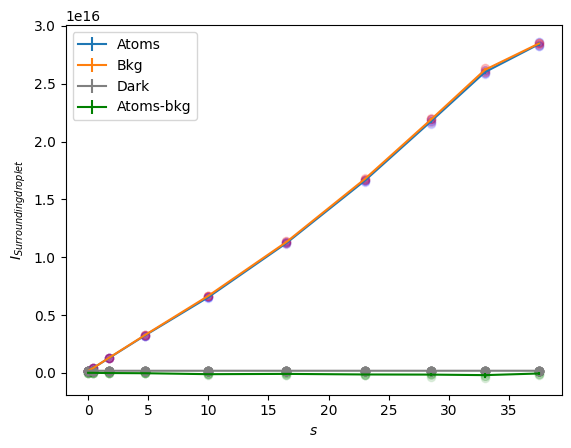

In [27]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat, dims = 2)), label="Atoms")
errorbar(sat_exp, vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Ibkg_surrounding_drop_per_sat, dims = 2)), label="Bkg")
errorbar(sat_exp, vec(mean(Idark_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Idark_surrounding_drop_per_sat, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2))-vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i], color="b", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_surrounding_drop[i], color="r", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i]-Ibkg_surrounding_drop[i], color="g", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Idark_surrounding_drop[i], color="grey")
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

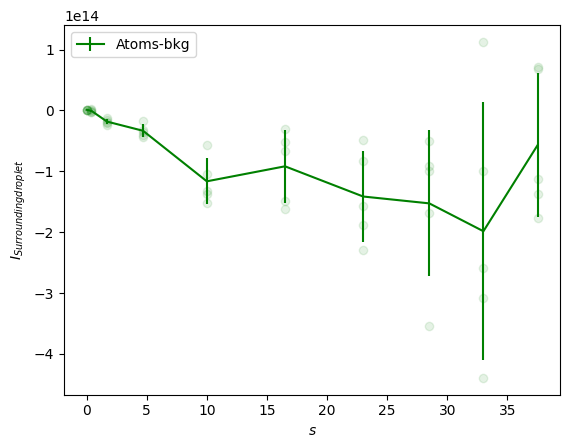

In [28]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2))-vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Atoms-bkg", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_surrounding_drop[i]-Ibkg_surrounding_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

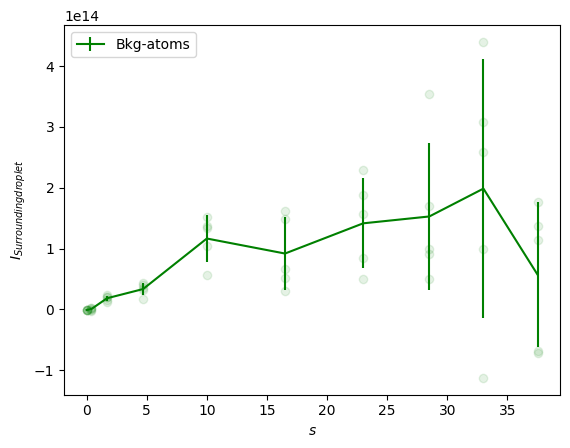

In [29]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Ibkg_surrounding_drop_per_sat, dims = 2))-vec(mean(Iatoms_surrounding_drop_per_sat, dims = 2)), yerr=vec(std(Iatoms_surrounding_drop_per_sat-Ibkg_surrounding_drop_per_sat, dims = 2)), label="Bkg-atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_surrounding_drop[i]-Iatoms_surrounding_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Surrounding droplet}")

legend()

# pygui(true); show();
pygui(false);

# Brouillons

In [30]:
# close("all")
# figure()
# img = imshow(imgs_atoms_crop[5]-imgs_bkg_crop[5])
# colorbar(img)
# pygui(true); show();


# ODs = compute_OD_high_low_intensity(imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop, dict_set_val_sat, intensities_imgs, τ_exp);

# close("all")
# fig, axs = subplots(1, 4, figsize=(15, 5))
# img = axs[1].imshow(ODs[5])
# # colorbar(img)

# xc, yc, a, b, θ = 310, 350, 110, 60, 1.1;
# mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

# axs[2].imshow(ODs[5].*(1 .-mask))

# axs[3].imshow(ODs[5].*mask)

# OD_mask = ODs[5].*mask

# axs[4].imshow(OD_mask .* (OD_mask .< 0))


# # pygui(true); show();
# pygui(false)